In [1]:
%pip install equinox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.4/178.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.3.0
    Uninstalling typeguard-4.3.0:
      Successfully uninstalled typeguard-4.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.9.0 requires scipy<1.14,>=1.4.1, but you have scipy 1.14.0 which is incompatible.
ydata-profiling 4.9.0 requires typeguard<5,>=3, but you have typeguard 2.13.3 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install --force-reinstall scipy==1.12.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 82.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.0
    Uninstalling scipy-1.14.0:
      Successfully uninstalled scipy-1.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf 24.8.2 requires cubinlinker, which is not installed.
cudf 24.8.2 requires cupy-cuda11x>=12.0.0, which is not installed.
cudf 24.8.2 requires ptxcompiler, which is not installed.
cuml 24.8.0 requires c

In [3]:
import jax
import jax.numpy as jnp

import scipy
scipy.__version__

'1.12.0'

In [4]:
jax.devices()

[cuda(id=0)]

In [5]:
#What coefficient to train
coefficient = "drag"

#Whether I am testing out architecture vs serious training
trial_mode = False

In [6]:
from torch.utils.data import Dataset
import pandas as pd
import numpy as np

input_labels = ["B", "T", "P", "C", "E", "R", "Alpha", "Re"]
#output_labels = ["Cl", "Cd", "Cdp", "Cm"]
if coefficient == "lift":
    output_labels = ["Cl"]
elif coefficient == "drag":
    output_labels = ["Cd"]
elif coefficient == "pdrag":
    output_labels = ["Cdp"]
elif coefficient == "moment":  
    output_labels = ["Cm"]
    
def clean_data(labels):
    #Filter out stall behaviour
    labels = labels[(labels["Alpha"] > -10) & (labels["Alpha"] < 10)]
    labels = labels[labels["Re"] > 200_000]
    
    return labels

class AirfoilTrainDataset(Dataset):
    def __init__(self, data_file):
        self.labels = pd.read_csv(data_file)
        
        #Filter out stall behaviour
        self.labels = clean_data(self.labels)

        #Split into train and validation
        split_point = int(len(self.labels) * 0.7)
        
        self.labels = self.labels[:split_point]
        
        self.input_labels = self.labels[input_labels]
        self.output_labels = self.labels[output_labels]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        input_df = self.input_labels.iloc[index]
        input_arr = np.array(input_df, dtype=jnp.float32)
        output_df = self.output_labels.iloc[index]
        output_arr = np.array(output_df, dtype=jnp.float32)
        return (input_arr, output_arr)
    
class AirfoilTestDataset(Dataset):
    def __init__(self, data_file):
        self.labels = pd.read_csv(data_file)
        
        #Filter out stall behaviour
        self.labels = clean_data(self.labels)
        
        #Split into train and validation
        split_point = int(len(self.labels) * 0.7)
        
        self.labels = self.labels[split_point:]
        
        self.input_labels = self.labels[input_labels]
        self.output_labels = self.labels[output_labels]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        input_df = self.input_labels.iloc[index]
        input_arr = np.array(input_df, dtype=jnp.float32)
        output_df = self.output_labels.iloc[index]
        output_arr = np.array(output_df, dtype=jnp.float32)
        return (input_arr, output_arr)

In [7]:
import equinox as eqx

class SurrogateModel(eqx.Module):
    
    layers: list
        
    def __init__(self, in_size, out_size, width_size, depth, activation, key):
        keys = jax.random.split(key, depth + 2)
        
        input_key = keys[0]
        output_key = keys[-1]
        hidden_keys = keys[1:-1]
        
        input_layer = eqx.nn.Linear(in_size, width_size, key=input_key)
        output_layer = eqx.nn.Linear(width_size, out_size, key=output_key)
        
        #Make Reynolds number on log10 scale
        @jax.jit
        def normalize_reynolds_number(x):
            Re = x[-1]
            Re = jnp.log10(Re)
            
            return jnp.hstack((x[:-1], Re))
            
        
        self.layers = [
            normalize_reynolds_number,
            jax.nn.standardize, #Standardize -1 to 1
            input_layer,
            activation
        ]
        for key in hidden_keys:
            self.layers.append(eqx.nn.Linear(width_size, width_size, key=key))
            self.layers.append(activation)
            
        self.layers.append(output_layer)
        
    def __call__(self, x):
                
        for layer in self.layers:
            x = layer(x)

        return x
        

In [8]:
# import equinox as eqx

# class BranchedSurrogateModel(eqx.Module):
    
#     shared_layers: list
#     branches: list
        
#     def __init__(self, in_size, out_size, shared_width, shared_layers, branch_width, branch_layers, activation, key):
#         input_key, shared_key, branch_key = jax.random.split(key, 3)
        
#         #Size of first hidden layer
#         first_hidden_size = shared_width if shared_layers > 0 else branch_width
        
#         input_layer = eqx.nn.Linear(in_size, first_hidden_size, key=input_key)
        
#         #Create shared layers
#         self.shared_layers = [
#             lambda x: jnp.hstack((x[:-1], jnp.log(x[-1]))), #Make reynolds number on log scale
#             jax.nn.standardize,
#             input_layer,
#             activation
#         ]
        
#         shared_keys = jax.random.split(shared_key, shared_layers)
#         for k in shared_keys:
#             self.shared_layers.append(eqx.nn.Linear(shared_width, shared_width, key=k))
#             self.shared_layers.append(activation)
        
#         self.branches = []
#         branch_keys = jax.random.split(branch_key, out_size)
#         #Create branches
#         for k in branch_keys:
#             branch_layers_list = []
#             branch_layer_keys = jax.random.split(k, branch_layers)
#             for idx, j in enumerate(branch_layer_keys):
#                 #If it's the first layer in the branch, the data flows from the shared layer
#                 branch_layer_input_size = shared_width if idx == 0 else branch_width
#                 branch_layers_list.append(eqx.nn.Linear(branch_layer_input_size, branch_width, key=j))
#                 branch_layers_list.append(activation)
#             #Output layer
#             branch_layers_list.append(eqx.nn.Linear(branch_width, 1, key=k))
            
#             self.branches.append(branch_layers_list)
            
#     def call_layer(self, layer, x):
#         for f in layer:
#             x = f(x)
#         return x
                        
#     def __call__(self, x):
#         x = self.call_layer(self.shared_layers, x)
            
#         results = []
#         for branch in self.branches:
#             results.append(self.call_layer(branch, x))
            
#         return jnp.hstack(results)

In [9]:
key = jax.random.PRNGKey(42)

# model = SurrogateModel(
#     in_size=len(input_labels),
#     out_size=len(output_labels),
#     shared_width=128,
#     shared_layers=2,
#     branch_width=64,
#     branch_layers=4,
#     activation=jax.nn.tanh,
#     key=key
# )

model = SurrogateModel(
    in_size=len(input_labels),
    out_size=len(output_labels),
    width_size=64,
    depth=4,
    activation=jax.nn.silu,
    key=key
)

model

SurrogateModel(
  layers=[
    <wrapped function normalize_reynolds_number>,
    <wrapped function standardize>,
    Linear(
      weight=f32[64,8],
      bias=f32[64],
      in_features=8,
      out_features=64,
      use_bias=True
    ),
    <wrapped function silu>,
    Linear(
      weight=f32[64,64],
      bias=f32[64],
      in_features=64,
      out_features=64,
      use_bias=True
    ),
    <wrapped function silu>,
    Linear(
      weight=f32[64,64],
      bias=f32[64],
      in_features=64,
      out_features=64,
      use_bias=True
    ),
    <wrapped function silu>,
    Linear(
      weight=f32[64,64],
      bias=f32[64],
      in_features=64,
      out_features=64,
      use_bias=True
    ),
    <wrapped function silu>,
    Linear(
      weight=f32[64,64],
      bias=f32[64],
      in_features=64,
      out_features=64,
      use_bias=True
    ),
    <wrapped function silu>,
    Linear(
      weight=f32[1,64],
      bias=f32[1],
      in_features=64,
      out_features=1,


In [10]:
@eqx.filter_jit
def loss(model, x, y):
    y_hat = jax.vmap(model)(x)
    
    #MSE Loss
    return jnp.mean((y - y_hat) ** 2)

@eqx.filter_jit
def training_step(model, opt_state, optim, x, y):
    loss_val, loss_grad = eqx.filter_value_and_grad(loss)(model, x, y)
    
    updates, opt_state = optim.update(loss_grad, opt_state)
    
    model = eqx.apply_updates(model, updates)
    
    return model, opt_state, loss_val

In [11]:
dataset_file = "airfoils_xs.csv" if trial_mode else "airfoils.csv"

In [12]:
import optax
from torch.utils.data import DataLoader
from IPython.display import clear_output
import math
import time

batch_size = 200
lr = 1e-3
epochs = 2000 if trial_mode else 1000

if not trial_mode:
    try:
        model = eqx.tree_deserialise_leaves(f"/kaggle/input/{coefficient}_surrogate.eqx", model)
    except:
        print("WARNING: No base model to continue training off of. Starting training from scratch.")

dataset = AirfoilTrainDataset(f"/kaggle/input/{dataset_file}")
training_dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

optim = optax.adabelief(learning_rate=lr)
opt_state = optim.init(eqx.filter(model, eqx.is_array))

for i in range(epochs):
    print("Training epoch",i)
    start_time = time.time()
    
    total_losses = []
    j = 1
    for x, y in training_dataloader:
        #print("\rBatch", j, "of", len(training_dataloader), end=" " * 20)
        x = jnp.array(x, dtype=jnp.float32)
        y = jnp.array(y, dtype=jnp.float32)
                
        model, opt_state, loss_val = training_step(model, opt_state, optim, x, y)
        total_losses.append(loss_val)
        j += 1
    clear_output()

    total_losses = jnp.array(total_losses)
    print(f"Avg. Loss: {jnp.mean(total_losses):e}")
    print(f"Min. Loss: {jnp.min(total_losses):e}")
    print(f"Max. Loss {jnp.max(total_losses):e}")
    
    duration = time.time() - start_time
    print("Epoch took", duration, "seconds")
    
    if i % 5 == 0 and i != 0:
        eqx.tree_serialise_leaves(f"/kaggle/working/{coefficient}_surrogate.eqx", model)
        print(f"Saved checkpoint to /kaggle/working/{coefficient}_surrogate.eqx")
        if loss_val < 1e-6:
            print("Loss value is", loss_val, "cutting training early.")
            break

Avg. Loss: 3.022409e-05
Min. Loss: 7.456545e-06
Max. Loss 1.720465e-03
Epoch took 25.489992141723633 seconds


Running validation...
Validation MAE loss (drag) 0.006789084
MSE loss 0.0016111281


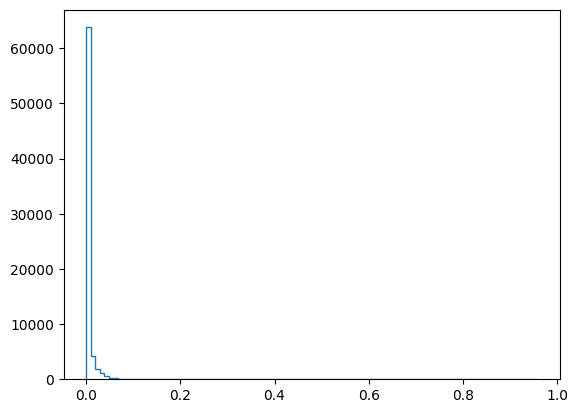

In [13]:
import matplotlib.pyplot as plt

model = eqx.tree_deserialise_leaves(f"/kaggle/working/{coefficient}_surrogate.eqx", model)

validation_dataset = AirfoilTestDataset(f"/kaggle/input/{dataset_file}")
x, y = list(DataLoader(dataset=validation_dataset, batch_size=len(validation_dataset), shuffle=False))[0]

x = jnp.array(x, dtype=jnp.float32)
y = jnp.array(y, dtype=jnp.float32)

y_hat = jax.vmap(model)(x)

abs_error = jnp.abs(y - y_hat)


print("Running validation...")
print(f"Validation MAE loss ({coefficient})", jnp.mean(abs_error))
print("MSE loss", jnp.mean(abs_error ** 2))

plt.hist(abs_error.flatten(), bins=100, histtype='step')

plt.show()

In [14]:
#! rm /kaggle/working/surrogate.eqx

Reynolds number 500000.0
[[-1.1342751e-02  4.7428566e-03  2.3346392e-02  3.4841903e-02
  -3.0696562e-02 -1.6986009e-02 -7.7417586e-05 -3.3253200e-09]]


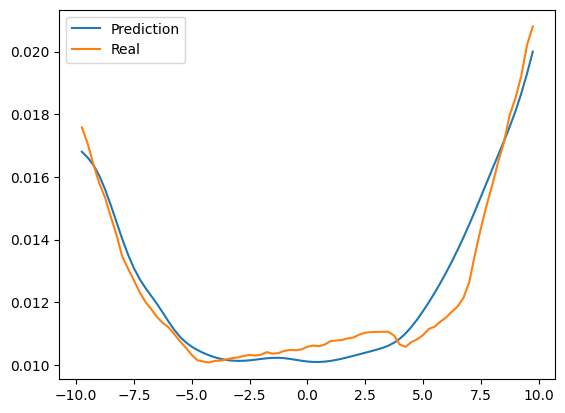

In [15]:
import jax
import jax.numpy as jnp
import equinox as eqx
import matplotlib.pyplot as plt
import random

input_labels = ["B", "T", "P", "C", "E", "R", "Alpha", "Re"]

if coefficient == "lift":
    output_labels = ["Cl"]
elif coefficient == "drag":
    output_labels = ["Cd"]
elif coefficient == "pdrag":
    output_labels = ["Cdp"]
elif coefficient == "moment":  
    output_labels = ["Cm"]

key = jax.random.PRNGKey(42)

# model = BranchedSurrogateModel(
#     in_size=len(input_labels),
#     out_size=len(output_labels),
#     shared_width=128,
#     shared_layers=2,
#     branch_width=64,
#     branch_layers=4,
#     activation=jax.nn.tanh,
#     key=key
# )
model = SurrogateModel(
    in_size=len(input_labels),
    out_size=len(output_labels),
    width_size=64,
    depth=4,
    activation=jax.nn.silu,
    key=key
)

try:
    model = eqx.tree_deserialise_leaves(f"/kaggle/working/{coefficient}_surrogate.eqx", model)
except:
    print("No model available")
    
#It's fine if it's overfitting
validation_dataset = AirfoilTrainDataset(f"/kaggle/input/{dataset_file}")

geometry_params = validation_dataset[0][0][:6]
Re = validation_dataset[0][0][-1]

print("Reynolds number", Re)

num_rows = 0
while (validation_dataset[num_rows][0][:6] == geometry_params).all() and (validation_dataset[num_rows][0][-1] == Re).all():
    num_rows += 1
    
alpha = []
#Real coefficients
real_polars = []
for row in range(num_rows):
    alpha.append(validation_dataset[row][0][-2])
    real_polars.append(validation_dataset[row][1])
    
real_coefficients = jnp.vstack(real_polars).T.flatten()
    
jacobian = jax.jacrev(model)(jnp.hstack((geometry_params, 0, Re)))
print(jacobian)
    
alpha = jnp.array(alpha).reshape(1, -1).T
Re = jnp.full(alpha.shape, Re)



# alpha = jnp.linspace(-15, 15, 20).reshape(1, -1).T
# Re = jnp.full(alpha.shape, 100_000)
# geometry_params = jnp.array([
#     1.506811261177063, 
#     0.0689479857683181,
#     2.998674869537353,
#     0.0746447443962097,
#     0.9967032074928284,
#     0.0162249598652124
# ])

#Get Jacobian of example airfoil

geometry_params = jnp.full((alpha.size, geometry_params.size), geometry_params)

all_params = jnp.hstack((geometry_params, alpha, Re))

results = jax.vmap(model)(all_params)
coefficients = results.T.flatten()

alpha = alpha.flatten()

f, ax = plt.subplots(1, 1)


ax.plot(alpha, coefficients, label="Prediction")
ax.plot(alpha, real_coefficients, label="Real")
ax.legend()

plt.show()